# COMP5329 — Deep Learning

**Tutorial — Convolutional Neural Networks**

**Semester 1, 2026**

### Learning Objectives
By the end of this tutorial you will be able to:

1. Load **MNIST** and apply **data augmentation**.
2. Implement **`ConvLayer`** with the im2col trick (`F.unfold` + matrix multiply).
3. Implement **`PoolLayer`** for max- and average-pooling.
4. Implement **`LinearLayer`** (Week 3 interface, autograd backward).
5. Use these building blocks to build and compare:
   - **AlexNet** (2012) — depth + ReLU + Dropout
   - **VGG-11**  (2014) — stacked 3×3 kernels
   - **ResNet**  (2015) — residual skip connections
6. Create **Agent Skills** (`SKILL.md`) with metadata fields (`allowed-tools`, `context`, `model`) and instruction bodies including argument placeholders and pre-processing shell commands
7. Understand the **execution mechanism** of skills — context injection, auto-invocation, and the difference between default (`context: default`) and forked (`context: fork`) execution
8. Understand **subagents** as isolated specialist processes and choose the right tool type (`Explore`, `Plan`, `general-purpose`) based on the task
9. Decide when to use **inline skills vs forked skills vs subagents** using the context-visibility trade-off framework

---
## §0 — MNIST Dataset & DataLoader

### What is MNIST?

MNIST (*Modified National Institute of Standards and Technology*) is the
classic benchmark for image classification:

| Property | Value |
|---|---|
| Input | 28 × 28 grayscale images |
| Classes | 10 (digits 0–9) |
| Training set | 60 000 images |
| Test set | 10 000 images |

`torchvision.datasets.MNIST` downloads and caches the data automatically.
`torchvision.transforms` converts PIL images to normalised float tensors.

Unlike Weeks 3–4, this week we use the **official `torch.utils.data.DataLoader`**
— loading 28×28 images efficiently from disk is exactly the use-case it was
designed for.

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

torch.manual_seed(42)

# ── Transforms ─────────────────────────────────────────────────────────────
# ToTensor()   : PIL image (H,W) uint8  →  float tensor (1,H,W) in [0,1]
# Normalize()  : (x - mean) / std      →  approximately centred around 0
MEAN, STD = 0.1307, 0.3081          # MNIST global statistics
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MEAN,), (STD,)),
])

# ── Download / load ─────────────────────────────────────────────────────────
train_dataset = datasets.MNIST(root='./data', train=True,  download=True,  transform=base_transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True,  transform=base_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0)

imgs, labels = next(iter(train_loader))
print(f'Training samples : {len(train_dataset):,}')
print(f'Test samples     : {len(test_dataset):,}')
print(f'Batch shape      : {imgs.shape}   # (N, C, H, W)')
print(f'Label shape      : {labels.shape}')
print(f'Pixel range      : [{imgs.min():.2f}, {imgs.max():.2f}]  (after normalisation)')

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:02<00:00, 3326990.05it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 147839.32it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:01<00:00, 940971.53it/s] 


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 2438935.96it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Training samples : 60,000
Test samples     : 10,000
Batch shape      : torch.Size([64, 1, 28, 28])   # (N, C, H, W)
Label shape      : torch.Size([64])
Pixel range      : [-0.42, 2.82]  (after normalisation)


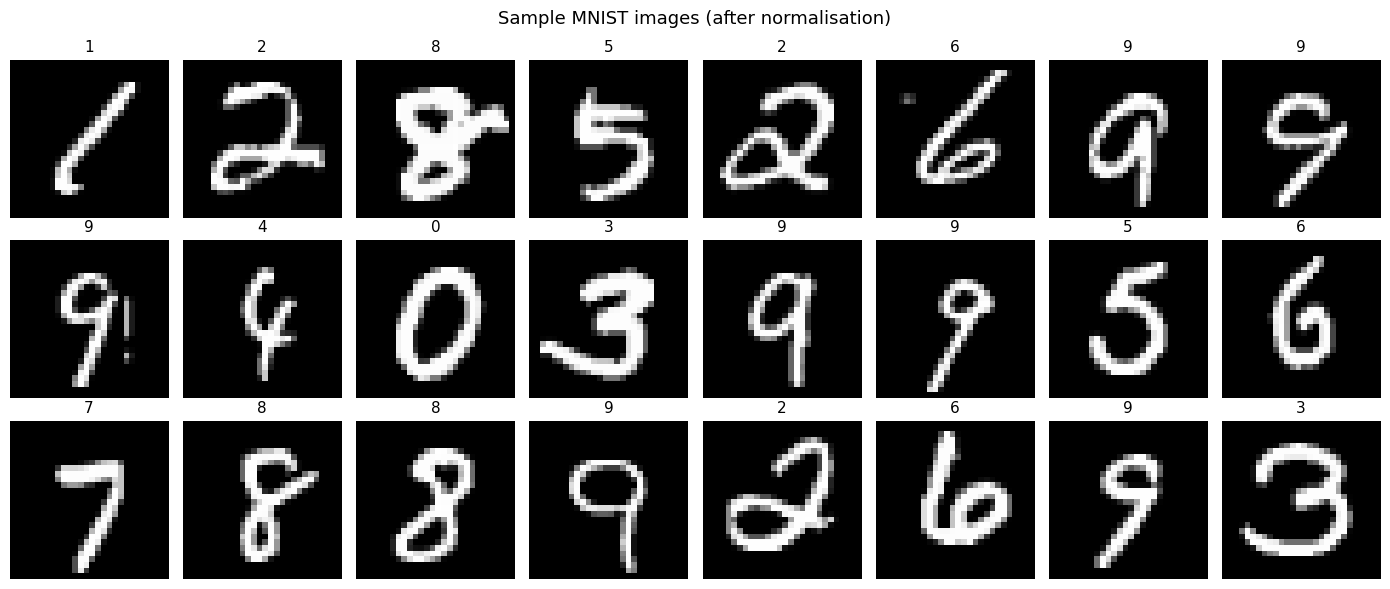

In [2]:
# ── Visualise a sample batch ────────────────────────────────────────────────
fig, axes = plt.subplots(3, 8, figsize=(14, 6))
for ax, img, lbl in zip(axes.flat, imgs[:24], labels[:24]):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(lbl.item(), fontsize=11)
    ax.axis('off')
fig.suptitle('Sample MNIST images (after normalisation)', fontsize=13)
plt.tight_layout()
plt.show()

---
## §1 — Data Augmentation

### Why augment?

Training on the *same* images every epoch risks **memorisation**.
Augmentation creates synthetic variations at training time, making the
model more **robust** and **generalisable** — effectively a cheap way to
increase dataset size.

| Transform | What it does | Intuition |
|---|---|---|
| `RandomRotation(θ)` | Rotate by ±θ degrees | Digits written at slight angles |
| `RandomAffine` | Random shift / shear | Digit may not be perfectly centred |
| `RandomHorizontalFlip` | Mirror left–right | Symmetric digits (0, 1, 8) |
| `ColorJitter` | Brightness / contrast | Varied scanning conditions |
| `Normalize` | Standardise pixels | Consistent gradient magnitudes |

### Augmentation in the pipeline

Transforms are applied **on-the-fly** per batch, so each epoch the model
sees slightly different versions of every image.

```
Raw PIL image
    ↓  RandomRotation
    ↓  RandomAffine
    ↓  ToTensor      → float32 tensor in [0,1]
    ↓  Normalize     → zero-mean, unit-variance
```

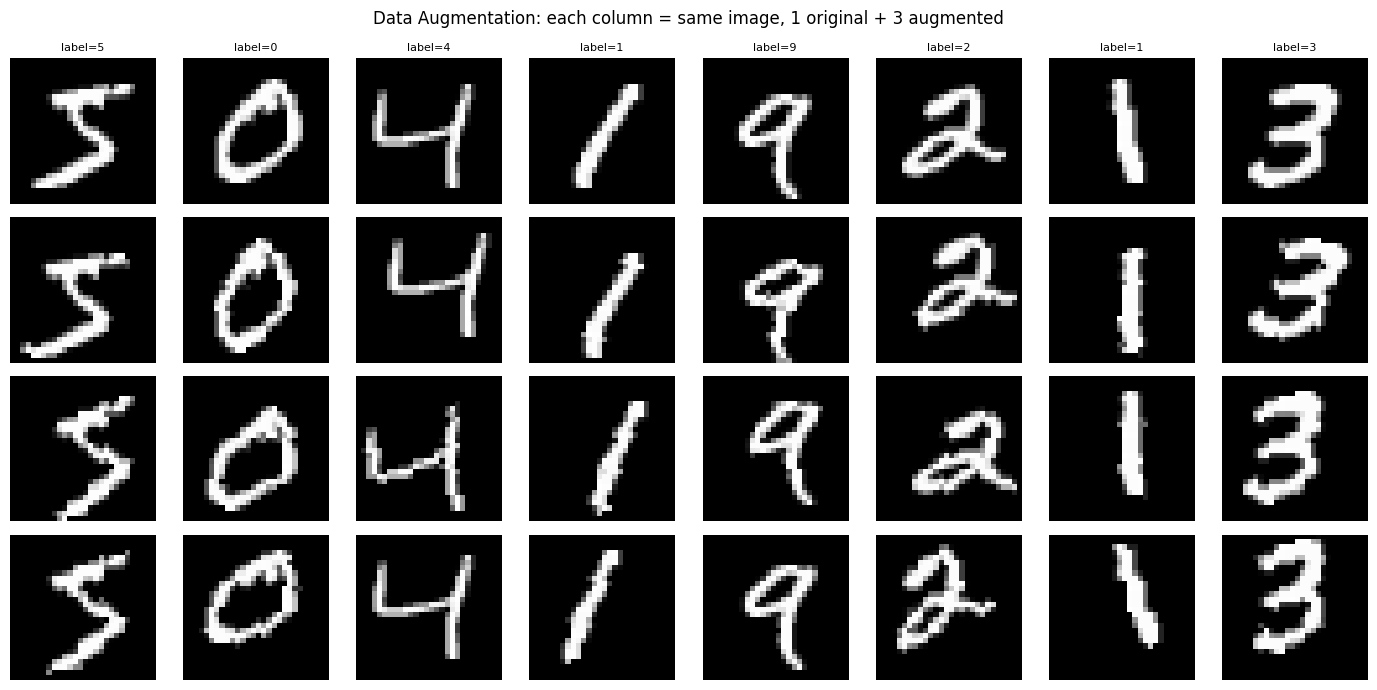

In [3]:
# ── Define augmented transform ─────────────────────────────────────────────
aug_transform = transforms.Compose([
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((MEAN,), (STD,)),
])

# Datasets for comparison (raw = no normalisation, for display)
raw_dataset = datasets.MNIST(root='./data', train=True, download=False,
                             transform=transforms.ToTensor())
aug_dataset = datasets.MNIST(root='./data', train=True, download=False,
                             transform=aug_transform)

# ── Side-by-side: original vs. three augmented views ───────────────────────
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle('Data Augmentation: each column = same image, 1 original + 3 augmented', fontsize=12)

for col in range(8):
    raw_img, lbl = raw_dataset[col]
    axes[0, col].imshow(raw_img.squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(f'label={lbl}', fontsize=8)
    axes[0, col].axis('off')
    for row in range(1, 4):
        aug_img, _ = aug_dataset[col]
        axes[row, col].imshow(aug_img.squeeze(), cmap='gray')
        axes[row, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10)
for r in range(1, 4):
    axes[r, 0].set_ylabel(f'Aug #{r}', fontsize=10)
plt.tight_layout()
plt.show()

### 1.2 — Effect of augmentation on generalisation

The visual comparison above shows *what* augmented images look like.
But *why does it help?*

**Setup:** Train the same tiny CNN twice on a **small subset (N = 1 000)**
of MNIST — small enough that the model can easily overfit.

| Run | Training data | Expected behaviour |
|---|---|---|
| No augmentation | 1 000 identical images per epoch | Memorises training set → high train acc, lower test acc |
| With augmentation | 1 000 randomly varied images per epoch | Can't memorise → forced to learn robust features |

The **overfitting gap** (train acc − test acc) is the key metric:
a smaller gap means better generalisation.

Training without augmentation...
Training with augmentation...


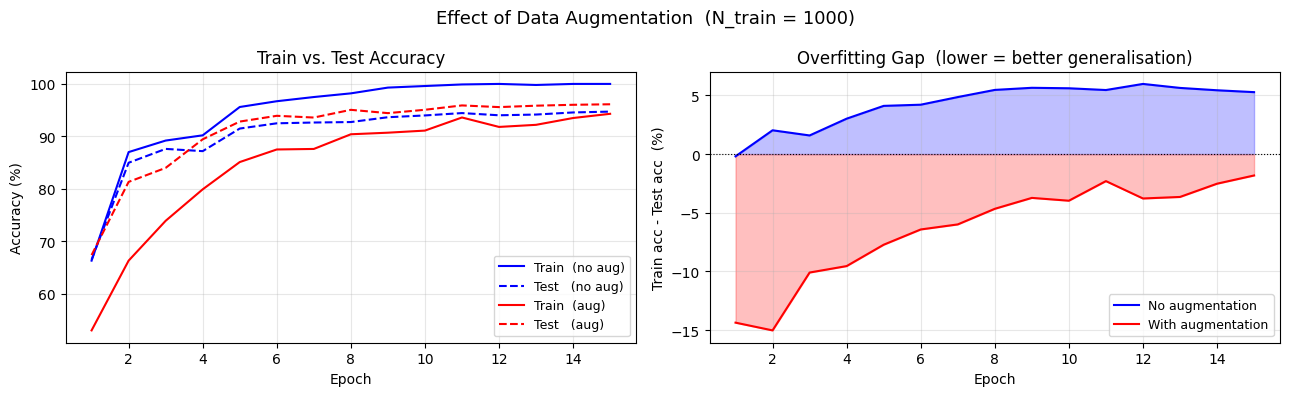

No augmentation : train=100.0%  test=94.7%  gap=5.3%
With augmentation: train=94.3%  test=96.1%  gap=-1.8%


In [4]:
# ── Effect demo: small dataset → overfitting visible ───────────────────────
N_SMALL = 1000
torch.manual_seed(0)
small_idx = torch.randperm(len(train_dataset))[:N_SMALL].tolist()

# Same indices, different transforms
loader_no_aug = torch.utils.data.DataLoader(
    torch.utils.data.Subset(
        datasets.MNIST('./data', train=True, download=False, transform=base_transform),
        small_idx),
    batch_size=32, shuffle=True)

loader_aug_eff = torch.utils.data.DataLoader(
    torch.utils.data.Subset(
        datasets.MNIST('./data', train=True, download=False, transform=aug_transform),
        small_idx),
    batch_size=32, shuffle=True)

# ── Tiny CNN (standard nn layers — ConvLayer defined later in §4) ───────────
def make_tiny_cnn():
    return nn.Sequential(
        nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Linear(32 * 7 * 7, 64), nn.ReLU(),
        nn.Linear(64, 10),
    )

def run_aug_experiment(train_loader, n_epochs=15):
    dev   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = make_tiny_cnn().to(dev)
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
    crit  = nn.CrossEntropyLoss()
    train_accs, test_accs = [], []
    for _ in range(n_epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(dev), y.to(dev)
            opt.zero_grad(); crit(model(x), y).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            # Train accuracy (on same small subset, without augmentation for fair eval)
            c = t = 0
            for x, y in train_loader:
                x, y = x.to(dev), y.to(dev)
                c += (model(x).argmax(1) == y).sum().item(); t += y.size(0)
            train_accs.append(c / t)
            # Test accuracy (full 10 000 test set)
            c = t = 0
            for x, y in test_loader:
                x, y = x.to(dev), y.to(dev)
                c += (model(x).argmax(1) == y).sum().item(); t += y.size(0)
            test_accs.append(c / t)
    return train_accs, test_accs

print('Training without augmentation...')
tr_raw, te_raw = run_aug_experiment(loader_no_aug)
print('Training with augmentation...')
tr_aug, te_aug = run_aug_experiment(loader_aug_eff)

# ── Plot ────────────────────────────────────────────────────────────────────
epochs = range(1, len(tr_raw) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Effect of Data Augmentation  (N_train = {N_SMALL})', fontsize=13)

axes[0].plot(epochs, [a*100 for a in tr_raw], 'b-',  label='Train  (no aug)')
axes[0].plot(epochs, [a*100 for a in te_raw], 'b--', label='Test   (no aug)')
axes[0].plot(epochs, [a*100 for a in tr_aug], 'r-',  label='Train  (aug)')
axes[0].plot(epochs, [a*100 for a in te_aug], 'r--', label='Test   (aug)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Train vs. Test Accuracy'); axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

gap_raw = [(tr - te) * 100 for tr, te in zip(tr_raw, te_raw)]
gap_aug = [(tr - te) * 100 for tr, te in zip(tr_aug, te_aug)]
axes[1].fill_between(epochs, gap_raw, alpha=0.25, color='blue')
axes[1].fill_between(epochs, gap_aug, alpha=0.25, color='red')
axes[1].plot(epochs, gap_raw, 'b-', label='No augmentation')
axes[1].plot(epochs, gap_aug, 'r-', label='With augmentation')
axes[1].axhline(0, color='k', linewidth=0.8, linestyle=':')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Train acc - Test acc  (%)')
axes[1].set_title('Overfitting Gap  (lower = better generalisation)')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f'No augmentation : train={tr_raw[-1]*100:.1f}%  '
      f'test={te_raw[-1]*100:.1f}%  gap={gap_raw[-1]:.1f}%')
print(f'With augmentation: train={tr_aug[-1]*100:.1f}%  '
      f'test={te_aug[-1]*100:.1f}%  gap={gap_aug[-1]:.1f}%')

---
## §2 — Convolution Layer

### 2.1 — What is a 2D convolution?

A convolution slides a small **filter (kernel)** of size $k \times k$
across the input, computing a dot product at each position:

$$
\text{output}[i, j] = \sum_{m=0}^{k-1} \sum_{n=0}^{k-1}
\text{input}[i \cdot s + m,\; j \cdot s + n] \times W[m, n] + b
$$

| Symbol | Meaning |
|---|---|
| $k$ | Kernel size (e.g. 3 → 3×3) |
| $s$ | Stride (step size between positions) |
| $p$ | Padding (zeros added around the border) |
| $C_{\text{in}}$ | Input channels |
| $C_{\text{out}}$ | Number of learned filters = output channels |

**Output spatial size:**
$$H_{\text{out}} = \left\lfloor \frac{H_{\text{in}} + 2p - k}{s} \right\rfloor + 1$$

### 2.2 — Common hand-crafted filters

Before *learning* filters, let's see what hand-crafted kernels detect:

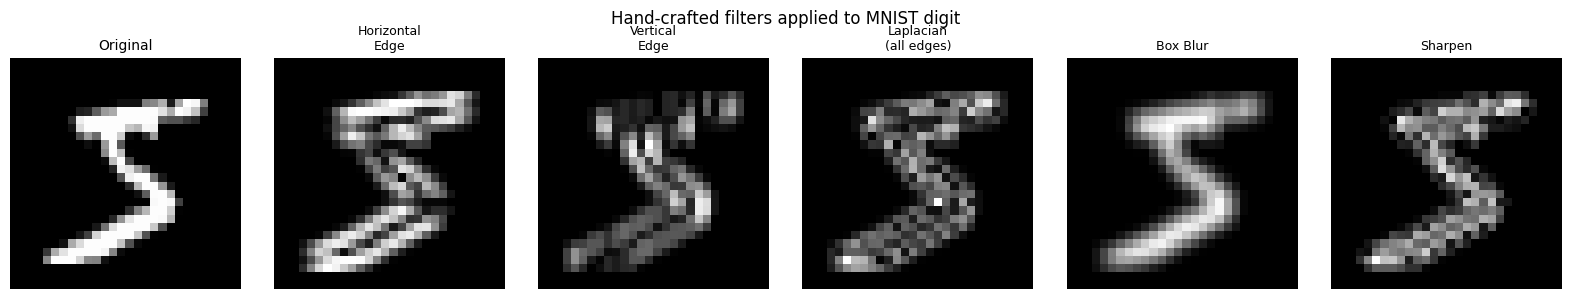

In [5]:
# ── Apply hand-crafted filters to a real MNIST digit ───────────────────────
raw_img_np = raw_dataset[0][0].squeeze().numpy()   # (28, 28), float [0,1]

def manual_conv2d(img, kernel, padding=1):
    """Pure NumPy 2D cross-correlation (stride=1)."""
    k = kernel.shape[0]
    h, w = img.shape
    if padding:
        img = np.pad(img, padding, mode='constant')
    out = np.zeros((h, w))
    for i in range(h):
        for j in range(w):
            out[i, j] = (img[i:i+k, j:j+k] * kernel).sum()
    return out

kernels = {
    'Horizontal\nEdge': np.array([[ 1,  1,  1],
                                   [ 0,  0,  0],
                                   [-1, -1, -1]], dtype=float),
    'Vertical\nEdge':   np.array([[-1,  0,  1],
                                   [-1,  0,  1],
                                   [-1,  0,  1]], dtype=float),
    'Laplacian\n(all edges)': np.array([[-1, -1, -1],
                                         [-1,  8, -1],
                                         [-1, -1, -1]], dtype=float),
    'Box Blur':         np.ones((3, 3), dtype=float) / 9,
    'Sharpen':          np.array([[ 0, -1,  0],
                                  [-1,  5, -1],
                                  [ 0, -1,  0]], dtype=float),
}

fig, axes = plt.subplots(1, len(kernels) + 1, figsize=(16, 3))
axes[0].imshow(raw_img_np, cmap='gray')
axes[0].set_title('Original', fontsize=10)
axes[0].axis('off')
for ax, (name, k) in zip(axes[1:], kernels.items()):
    out = manual_conv2d(raw_img_np, k)
    ax.imshow(np.abs(out), cmap='gray')
    ax.set_title(name, fontsize=9)
    ax.axis('off')
fig.suptitle('Hand-crafted filters applied to MNIST digit', fontsize=12)
plt.tight_layout()
plt.show()

### 2.3 — Learnable `ConvLayer`

Instead of hand-designing filters, we let the network **learn** $W$ from data.

**Key design:**
- Store `W` *(C_out, C_in, kH, kW)* and `b` *(C_out,)* as `nn.Parameter`
  — PyTorch registers them for autograd tracking.
- `forward()` calls `F.conv2d(x, self.W, self.b, ...)` — this is our
  implementation of the convolution computation.
- `backward()` is handled automatically by PyTorch's autograd, which
  differentiates through `F.conv2d` (it knows the gradient of a conv
  is a transposed convolution — complex to derive, but autograd does it
  for free).

This mirrors the Week 3/4 pattern exactly: we own the *forward logic*,
autograd owns the *differentiation*.

**Initialisation extended for 4-D tensors:**

For a conv kernel of shape *(C_out, C_in, kH, kW)*:
- $\text{fan\_in}  = C_{\text{in}}  \times k_H \times k_W$
- $\text{fan\_out} = C_{\text{out}} \times k_H \times k_W$

#### Two ways to implement convolution

**Implementation 1 — Naive loops** (教学演示，慢):

```python
for n in range(N):           # batch
  for f in range(C_out):     # filter
    for i in range(H_out):   # output row
      for j in range(W_out): # output col
        out[n,f,i,j] = (x_pad[n, :, i*s:i*s+k, j*s:j*s+k] * W[f]).sum() + b[f]
```

**Implementation 2 — im2col** (用于 `ConvLayer.forward()`):

The key insight: every receptive-field patch can be *flattened into a column*.
Convolution then becomes a **single batched matrix multiply**:

```
  Input x (N, C_in, H, W)
          │
    F.unfold (slide k×k window, flatten each patch into a column)
          │
  x_col  (N, C_in·kH·kW,  H_out·W_out)    W_row  (C_out, C_in·kH·kW)
          └──────────────────── @ ──────────────────────┘
                                │
                   out  (N, C_out, H_out·W_out)  →  reshape
                   (N, C_out, H_out, W_out)
```

Why im2col?
- `F.unfold` and matrix multiply `@` are both **tracked by autograd** — gradients flow correctly
- Replaces 4 nested Python loops with a single optimised BLAS/cuBLAS call

In [6]:
# ── Implementation 1: Naive loop-based conv (educational, not for training) ──
def naive_conv2d(x, W, b, stride=1, padding=0):
    """
    Convolution via explicit loops — shows raw computation step by step.
    x: (N, C_in, H, W)   W: (C_out, C_in, kH, kW)   b: (C_out,)

    For each output position (n, f, i, j):
        out[n,f,i,j] = Σ_{c,m,n} x_pad[n,c, i*s+m, j*s+n] * W[f,c,m,n] + b[f]
    """
    N, C_in, H, W_in = x.shape
    C_out, _, k, _   = W.shape
    x_pad = F.pad(x, [padding] * 4) if padding > 0 else x
    H_out = (H + 2 * padding - k) // stride + 1
    W_out = (W_in + 2 * padding - k) // stride + 1
    out   = torch.zeros(N, C_out, H_out, W_out, device=x.device)
    for n in range(N):                 # batch
        for f in range(C_out):         # output filter
            for i in range(H_out):     # output row
                for j in range(W_out): # output col
                    hs, ws = i * stride, j * stride
                    # receptive field (C_in,k,k) · filter (C_in,k,k) → scalar
                    out[n, f, i, j] = (
                        x_pad[n, :, hs:hs+k, ws:ws+k] * W[f]
                    ).sum() + b[f]
    return out


# ── Implementation 2: im2col — unfold patches → matrix multiply ──────────────
def my_conv2d(x, W, b, stride=1, padding=0):
    """
    Convolution via im2col:

    Step 1  F.unfold: slide a k×k window, pack each receptive-field patch
            as a column.  x_col: (N, C_in*kH*kW, H_out*W_out)

    Step 2  Flatten each filter kernel into a row.
            W_row: (C_out, C_in*kH*kW)

    Step 3  Batched matrix multiply  W_row @ x_col.
            out: (N, C_out, H_out*W_out)

    Step 4  Add bias, reshape to (N, C_out, H_out, W_out).

    Fully differentiable: F.unfold and @ both support autograd.
    """
    N, C_in, H, W_in = x.shape
    C_out, _, k, _   = W.shape
    H_out = (H + 2 * padding - k) // stride + 1
    W_out = (W_in + 2 * padding - k) // stride + 1

    # Step 1 — extract all k×k receptive-field patches as columns
    x_col = F.unfold(x, kernel_size=k, stride=stride, padding=padding)
    # x_col: (N, C_in*k*k, H_out*W_out)

    # Step 2 — flatten filter weights into rows
    W_row = W.view(C_out, -1)
    # W_row: (C_out, C_in*k*k)

    # Step 3 — single batched matrix multiply  (broadcasts over N)
    out = W_row @ x_col + b.view(1, -1, 1)
    # out: (N, C_out, H_out*W_out)

    # Step 4 — reshape spatial dimensions back
    return out.view(N, C_out, H_out, W_out)


# ── Verify all three give identical results ──────────────────────────────────
torch.manual_seed(7)
x_v = torch.randn(1, 1, 8, 8)   # small input for speed
W_v = torch.randn(4, 1, 3, 3)
b_v = torch.randn(4)

out_ref    = F.conv2d   (x_v, W_v, b_v, stride=1, padding=1)
out_naive  = naive_conv2d(x_v, W_v, b_v, stride=1, padding=1)
out_im2col = my_conv2d  (x_v, W_v, b_v, stride=1, padding=1)

print(f'Output shape              : {out_ref.shape}')
print(f'F.conv2d vs naive     max|diff|: {(out_ref - out_naive ).abs().max().item():.2e}')
print(f'F.conv2d vs my_conv2d max|diff|: {(out_ref - out_im2col).abs().max().item():.2e}')
print('All three implementations agree \u2713' if (out_ref - out_im2col).abs().max() < 1e-5
      else 'MISMATCH!')

# ── Visualise im2col: what does F.unfold produce? ────────────────────────────
x_tiny = torch.arange(16, dtype=torch.float).view(1, 1, 4, 4)  # 4×4 image, pixels 0..15
col    = F.unfold(x_tiny, kernel_size=2, stride=1, padding=0)
# col: (1, C_in*k*k=4, H_out*W_out=9)  — 9 patches of size 2×2
print(f'\nim2col demo: 4\u00d74 image, 2\u00d72 kernel, stride=1')
print(f'Original pixels:\n{x_tiny.squeeze().int()}')
print(f'col shape: {col.shape}  # each of 9 columns = one 2\u00d72 receptive field (flattened)')
print(f'Unfolded patches (9 columns, each = 4 flattened pixels):')
print(col.squeeze().int())

Output shape              : torch.Size([1, 4, 8, 8])
F.conv2d vs naive     max|diff|: 9.54e-07
F.conv2d vs my_conv2d max|diff|: 0.00e+00
All three implementations agree ✓

im2col demo: 4×4 image, 2×2 kernel, stride=1
Original pixels:
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15]], dtype=torch.int32)
col shape: torch.Size([1, 4, 9])  # each of 9 columns = one 2×2 receptive field (flattened)
Unfolded patches (9 columns, each = 4 flattened pixels):
tensor([[ 0,  1,  2,  4,  5,  6,  8,  9, 10],
        [ 1,  2,  3,  5,  6,  7,  9, 10, 11],
        [ 4,  5,  6,  8,  9, 10, 12, 13, 14],
        [ 5,  6,  7,  9, 10, 11, 13, 14, 15]], dtype=torch.int32)


In [7]:
# ── init_weights (supports 2-D linear and 4-D conv shapes) ─────────────────
def init_weights(method, shape):
    """
    Returns an initialised float tensor.
    shape: (out_ch, in_ch, kH, kW)  for conv layers
           (in_features, out_features) for linear layers
    """
    if method == 'zeros':
        return torch.zeros(*shape)
    if len(shape) == 4:                         # conv kernel
        fan_in  = shape[1] * shape[2] * shape[3]
        fan_out = shape[0] * shape[2] * shape[3]
    else:                                        # linear / 2-D
        fan_in, fan_out = shape[0], shape[1]
    if method == 'xavier':
        std = math.sqrt(2.0 / (fan_in + fan_out))
    elif method == 'he':
        std = math.sqrt(2.0 / fan_in)
    else:                                        # 'random'
        std = 0.01
    return torch.randn(*shape) * std


# ── ConvLayer ────────────────────────────────────────────────────────────────
class ConvLayer(nn.Module):
    """
    Convolutional layer.

    Forward  : F.conv2d(x, W, b, stride, padding)  — implemented here.
    Backward : handled by PyTorch autograd via nn.Parameter.

    Parameters
    ----------
    in_channels   : C_in
    out_channels  : number of learnable filters (= C_out)
    kernel_size   : k  (square kernel k × k)
    stride        : s  (default 1)
    padding       : p  (use p = k // 2 for 'same' spatial size)
    activation    : None | 'relu' | 'sigmoid' | 'tanh'
    initialization: 'he' | 'xavier' | 'zeros' | 'random'
    """
    def __init__(self, in_channels, out_channels, kernel_size,
                 stride=1, padding=0, activation=None, initialization='he'):
        super().__init__()
        k = kernel_size
        # W shape: (C_out, C_in, kH, kW)
        self.W = nn.Parameter(init_weights(initialization,
                                           (out_channels, in_channels, k, k)))
        self.b = nn.Parameter(torch.zeros(out_channels))
        self.stride     = stride
        self.padding    = padding
        self.activation = activation

    def forward(self, x):
        # x: (N, C_in, H, W)
        # Our own im2col implementation — no F.conv2d
        out = my_conv2d(x, self.W, self.b,
                        stride=self.stride, padding=self.padding)
        # out: (N, C_out, H_out, W_out)
        if   self.activation == 'relu':    out = F.relu(out)
        elif self.activation == 'sigmoid': out = torch.sigmoid(out)
        elif self.activation == 'tanh':    out = torch.tanh(out)
        return out

    def __repr__(self):
        C_out, C_in, k, _ = self.W.shape
        return (f'ConvLayer({C_in}\u2192{C_out}, k={k}, '
                f's={self.stride}, p={self.padding}, act={self.activation})')


# ── Sanity check ────────────────────────────────────────────────────────────
x_demo = torch.randn(2, 1, 28, 28)         # batch of 2 MNIST images
conv = ConvLayer(1, 8, kernel_size=3, padding=1, activation='relu')
out  = conv(x_demo)
print(conv)
print(f'Input  : {x_demo.shape}')
print(f'Output : {out.shape}   # H,W unchanged because p=k//2=1, s=1')
print(f'W shape: {conv.W.shape}  # (C_out, C_in, kH, kW)')
print(f'b shape: {conv.b.shape}')
print(f'Trainable params: {conv.W.numel() + conv.b.numel()}')

ConvLayer(1→8, k=3, s=1, p=1, act=relu)
Input  : torch.Size([2, 1, 28, 28])
Output : torch.Size([2, 8, 28, 28])   # H,W unchanged because p=k//2=1, s=1
W shape: torch.Size([8, 1, 3, 3])  # (C_out, C_in, kH, kW)
b shape: torch.Size([8])
Trainable params: 80


### 2.4 — Multi-channel convolution

When $C_{\text{in}} > 1$ (e.g. RGB: $C_{\text{in}} = 3$), each filter
has depth $C_{\text{in}}$:

$$
\text{output}_{b,f,i,j}
= \sum_{c=1}^{C_{\text{in}}} \sum_{m,n}
  \text{input}_{b,c,\,i \cdot s+m,\,j \cdot s+n} \times W_{f,c,m,n} + b_f
$$

The weight tensor **`W`** has shape **(C_out, C_in, kH, kW)** — one
$C_{\text{in}} \times k \times k$ volume per output filter.
`F.conv2d` handles all channels automatically; our `ConvLayer.forward()` is
identical for 1-channel (MNIST) and 3-channel (RGB) inputs.

In [8]:
# ── Multi-channel demo: 1 → 16 → 32 feature maps ──────────────────────────
x_rgb = torch.randn(4, 3, 32, 32)   # 4 RGB images of size 32×32
conv1 = ConvLayer(3,  16, kernel_size=3, padding=1, activation='relu')
conv2 = ConvLayer(16, 32, kernel_size=3, padding=1, activation='relu')

out1 = conv1(x_rgb)
out2 = conv2(out1)

print(f'Input              : {x_rgb.shape}')
print(f'After conv1 (3→16) : {out1.shape}')
print(f'After conv2 (16→32): {out2.shape}')
print(f'\nconv1 W shape: {conv1.W.shape}  # (C_out, C_in, kH, kW)')
print(f'Trainable params in conv1: {conv1.W.numel() + conv1.b.numel()}')
print(f'Trainable params in conv2: {conv2.W.numel() + conv2.b.numel()}')

Input              : torch.Size([4, 3, 32, 32])
After conv1 (3→16) : torch.Size([4, 16, 32, 32])
After conv2 (16→32): torch.Size([4, 32, 32, 32])

conv1 W shape: torch.Size([16, 3, 3, 3])  # (C_out, C_in, kH, kW)
Trainable params in conv1: 448
Trainable params in conv2: 4640


---
## §3 — Pooling Layer

### Why pool?

After convolution, feature maps are spatially large and redundant.
Pooling **downsamples** them by summarising non-overlapping patches:

| Mode | Operation | Property |
|---|---|---|
| **Max** pooling | Take the maximum in each $k \times k$ patch | Keeps strongest activation; sharpens features |
| **Avg** pooling | Take the mean in each $k \times k$ patch | Smoother; less sensitive to exact position |

Pooling also provides **translation invariance**: if a feature shifts by
a few pixels, the max-pool output is unchanged.

```
Input (N, C, H, W)  →  PoolLayer(k=2)  →  (N, C, H/2, W/2)
```

Pooling has **no learnable parameters** — it is a fixed operation.

#### Implementing pooling ourselves

Pooling is simpler than convolution because there are **no learnable weights**
and each output channel is computed **independently** from the same input channel.

We reuse the `F.unfold` trick from §2.3:

```
  x (N, C, H, W)
       │
  F.unfold (k×k window, stride s)
       │
  x_col (N, C·k·k, H_out·W_out)
       │
  view → (N, C, k·k, H_out·W_out)
       │
  .max(dim=2)   or   .mean(dim=2)     ← pool over the k·k patch
       │
  out (N, C, H_out·W_out) → view → (N, C, H_out, W_out)
```

Both `max()` and `mean()` are **tracked by autograd**:
- `max` backward routes the gradient to the argmax position (zero elsewhere)
- `mean` backward splits the gradient equally across all k·k positions

In [9]:
def my_max_pool2d(x, kernel_size, stride=None):
    """
    Max pooling via im2col:
    1. Unfold → (N, C·k·k, L)   where L = H_out · W_out
    2. View   → (N, C, k·k, L)
    3. max over the k·k patch dimension (dim=2)
    4. Reshape → (N, C, H_out, W_out)
    """
    if stride is None:
        stride = kernel_size
    N, C, H, W = x.shape
    k = kernel_size
    H_out = (H - k) // stride + 1
    W_out = (W - k) // stride + 1

    x_col = F.unfold(x, kernel_size=k, stride=stride)   # (N, C·k·k, H_out·W_out)
    x_col = x_col.view(N, C, k * k, H_out * W_out)      # (N, C, k·k, L)
    out   = x_col.max(dim=2).values                      # (N, C, L)  — max over patch
    return out.view(N, C, H_out, W_out)


def my_avg_pool2d(x, kernel_size, stride=None):
    """
    Average pooling via im2col:
    Same as max pooling but .mean(dim=2) instead of .max(dim=2).
    """
    if stride is None:
        stride = kernel_size
    N, C, H, W = x.shape
    k = kernel_size
    H_out = (H - k) // stride + 1
    W_out = (W - k) // stride + 1

    x_col = F.unfold(x, kernel_size=k, stride=stride)   # (N, C·k·k, H_out·W_out)
    x_col = x_col.view(N, C, k * k, H_out * W_out)      # (N, C, k·k, L)
    out   = x_col.mean(dim=2)                            # (N, C, L)  — mean over patch
    return out.view(N, C, H_out, W_out)


# ── Verify against PyTorch builtins ─────────────────────────────────────────
torch.manual_seed(3)
x_v = torch.randn(2, 3, 8, 8)

for k, s in [(2, 2), (3, 1), (2, 1)]:
    ref_max = F.max_pool2d(x_v, k, s)
    ref_avg = F.avg_pool2d(x_v, k, s)
    my_max  = my_max_pool2d(x_v, k, s)
    my_avg  = my_avg_pool2d(x_v, k, s)
    d_max   = (ref_max - my_max).abs().max().item()
    d_avg   = (ref_avg - my_avg).abs().max().item()
    print(f'k={k}, s={s}  '
          f'max_pool max|diff|={d_max:.2e}  '
          f'avg_pool max|diff|={d_avg:.2e}  '
          f'out={tuple(ref_max.shape)}')
print('All correct \u2713')

k=2, s=2  max_pool max|diff|=0.00e+00  avg_pool max|diff|=0.00e+00  out=(2, 3, 4, 4)
k=3, s=1  max_pool max|diff|=0.00e+00  avg_pool max|diff|=5.96e-08  out=(2, 3, 6, 6)
k=2, s=1  max_pool max|diff|=0.00e+00  avg_pool max|diff|=0.00e+00  out=(2, 3, 7, 7)
All correct ✓


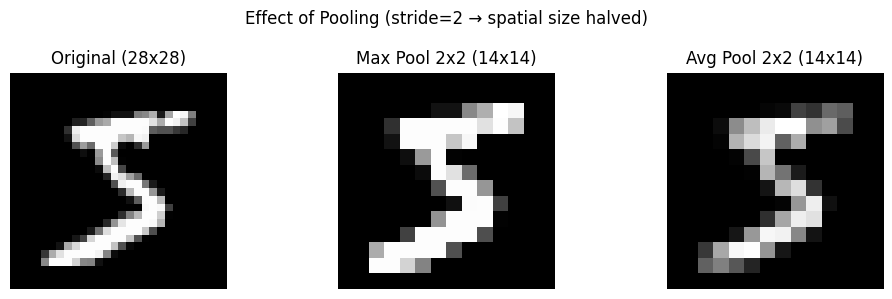

Input: torch.Size([1, 1, 28, 28])  →  After pooling: torch.Size([1, 14, 14])


In [10]:
# ── PoolLayer ────────────────────────────────────────────────────────────────
class PoolLayer(nn.Module):
    """
    Spatial pooling layer (no learnable parameters).

    Parameters
    ----------
    kernel_size : patch size (square)
    stride      : step; defaults to kernel_size (non-overlapping patches)
    mode        : 'max' | 'avg'
    """
    def __init__(self, kernel_size, stride=None, mode='max'):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride      = stride if stride is not None else kernel_size
        self.mode        = mode

    def forward(self, x):
        if self.mode == 'max':
            return my_max_pool2d(x, self.kernel_size, self.stride)
        else:
            return my_avg_pool2d(x, self.kernel_size, self.stride)

    def __repr__(self):
        return f'PoolLayer(k={self.kernel_size}, s={self.stride}, mode={self.mode})'


# ── Visual comparison: max vs avg pooling ───────────────────────────────────
raw_img_t = raw_dataset[0][0]           # (1, 28, 28)
x_single  = raw_img_t.unsqueeze(0)      # (1, 1, 28, 28)  — batch of 1

pool_max  = PoolLayer(2, mode='max')
pool_avg  = PoolLayer(2, mode='avg')

out_max   = pool_max(x_single).squeeze()    # (14, 14)
out_avg   = pool_avg(x_single).squeeze()    # (14, 14)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(x_single.squeeze(), cmap='gray');  axes[0].set_title('Original (28x28)');    axes[0].axis('off')
axes[1].imshow(out_max.detach(),   cmap='gray');  axes[1].set_title('Max Pool 2x2 (14x14)'); axes[1].axis('off')
axes[2].imshow(out_avg.detach(),   cmap='gray');  axes[2].set_title('Avg Pool 2x2 (14x14)'); axes[2].axis('off')
fig.suptitle('Effect of Pooling (stride=2 → spatial size halved)', fontsize=12)
plt.tight_layout()
plt.show()
print(f'Input: {x_single.shape}  →  After pooling: {out_max.unsqueeze(0).shape}')

---
## §4 — Linear Layer

### `LinearLayer` — the same Week 3 concept, now with autograd

In Week 3 we implemented `HiddenLayer` with **manual backprop**.
Now that `ConvLayer` relies on autograd, we use the same interface but
backed by `nn.Parameter` so gradients flow automatically:

```
LinearLayer: x → x @ W + b → activation(·)
```

The interface is identical — `forward(x)` returns the activated output.

In [11]:
# ── LinearLayer ──────────────────────────────────────────────────────────────
class LinearLayer(nn.Module):
    """
    Fully-connected layer (same concept as Week 3 HiddenLayer).

    Parameters
    ----------
    in_features  : input dimension
    out_features : output dimension
    activation   : None | 'relu' | 'sigmoid' | 'tanh'
    initialization: 'xavier' | 'he' | 'zeros' | 'random'
    """
    def __init__(self, in_features, out_features,
                 activation=None, initialization='xavier'):
        super().__init__()
        self.W = nn.Parameter(init_weights(initialization,
                                           (in_features, out_features)))
        self.b = nn.Parameter(torch.zeros(out_features))
        self.activation = activation

    def forward(self, x):
        out = x @ self.W + self.b
        if   self.activation == 'relu':    out = F.relu(out)
        elif self.activation == 'sigmoid': out = torch.sigmoid(out)
        elif self.activation == 'tanh':    out = torch.tanh(out)
        return out

    def __repr__(self):
        in_f, out_f = self.W.shape
        return f'LinearLayer({in_f}\u2192{out_f}, act={self.activation})'

In [12]:
# ── Shared training helpers (used by AlexNet, VGG-11, ResNet) ──────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


def train_model(model, n_epochs=3, lr=1e-3):
    """Train for n_epochs; return list of (avg_loss, test_acc) per epoch."""
    model = model.to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    crit  = nn.CrossEntropyLoss()
    history = []
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward()
            opt.step()
            total_loss += loss.item()
        acc = evaluate(model)
        history.append((total_loss / len(train_loader), acc))
        print(f'  Epoch {epoch+1}/{n_epochs}  '
              f'loss={history[-1][0]:.4f}  test_acc={acc:.4f}')
    return history


def evaluate(model):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1) == y).sum().item()
            total   += y.size(0)
    return correct / total


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Device: cuda


---
## §5 — AlexNet (2012)

### Historical context

AlexNet won the **ImageNet LSVRC 2012** competition with a top-5 error of
**15.3%** — more than 10 percentage points ahead of the runner-up.
It convinced the community that deep CNNs could dominate vision tasks.

### Key innovations

| Innovation | Contribution |
|---|---|
| **ReLU activation** | Faster training than sigmoid/tanh; avoids vanishing gradients |
| **GPU training** | Split across two GPUs; made training 60M params feasible |
| **Dropout** | Regularisation in FC layers (p = 0.5) |
| **Data augmentation** | Random crops, horizontal flips |
| **Local response normalisation** | (Later superseded by Batch Norm) |

### Original architecture (ImageNet, 224×224 RGB)

```
Input   (N, 3, 224, 224)
  Conv1  (3→96,  k=11, s=4, p=2)   → (N, 96, 55, 55)   MaxPool(3,s=2) → (N, 96, 27, 27)
  Conv2  (96→256, k=5, p=2)         → (N, 256, 27, 27)  MaxPool(3,s=2) → (N, 256, 13, 13)
  Conv3  (256→384, k=3, p=1)
  Conv4  (384→384, k=3, p=1)
  Conv5  (384→256, k=3, p=1)        → (N, 256, 13, 13)  MaxPool(3,s=2) → (N, 256, 6, 6)
  Flatten → (N, 9216)
  FC1 (9216→4096, relu, dropout)
  FC2 (4096→4096, relu, dropout)
  FC3 (4096→1000)
```

### MNIST adaptation (28×28, 1 channel)

We replace the first large-stride conv (designed for 224×224) with
standard 3×3 convolutions, and reduce filter counts to suit MNIST's
small spatial size:

```
Input   (N, 1, 28, 28)
  Conv1  (1→64,   k=3, p=1, relu)  → (N,  64, 28, 28)  MaxPool(2) → (N,  64, 14, 14)
  Conv2  (64→192, k=3, p=1, relu)  → (N, 192, 14, 14)  MaxPool(2) → (N, 192,  7,  7)
  Conv3  (192→384,k=3, p=1, relu)
  Conv4  (384→256,k=3, p=1, relu)
  Conv5  (256→256,k=3, p=1, relu)  → (N, 256,  7,  7)  MaxPool(2) → (N, 256,  3,  3)
  Flatten → (N, 2304)
  FC1 (2304→512, relu, dropout=0.5)
  FC2  (512→256, relu, dropout=0.5)
  FC3  (256→10)
```

In [13]:
class AlexNet(nn.Module):
    """
    AlexNet adapted for MNIST (28×28, 1-channel, 10 classes).
    Built entirely from our ConvLayer + PoolLayer + LinearLayer blocks.
    """
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()
        # ── Feature extractor (5 conv + 3 pool) ───────────────────────
        self.conv1 = ConvLayer(1,   64,  kernel_size=3, padding=1, activation='relu')
        self.pool1 = PoolLayer(2, mode='max')
        self.conv2 = ConvLayer(64,  192, kernel_size=3, padding=1, activation='relu')
        self.pool2 = PoolLayer(2, mode='max')
        self.conv3 = ConvLayer(192, 384, kernel_size=3, padding=1, activation='relu')
        self.conv4 = ConvLayer(384, 256, kernel_size=3, padding=1, activation='relu')
        self.conv5 = ConvLayer(256, 256, kernel_size=3, padding=1, activation='relu')
        self.pool3 = PoolLayer(2, mode='max')
        # ── Classifier (3 FC + dropout) ────────────────────────────────
        self.drop = nn.Dropout(dropout)
        self.fc1  = LinearLayer(256 * 3 * 3, 512, activation='relu')
        self.fc2  = LinearLayer(512, 256,         activation='relu')
        self.fc3  = LinearLayer(256, num_classes)

    def forward(self, x, return_fmaps=False):
        f1 = self.conv1(x)                # (N,  64, 28, 28)
        x  = self.pool1(f1)               # (N,  64, 14, 14)
        f2 = self.conv2(x)                # (N, 192, 14, 14)
        x  = self.pool2(f2)               # (N, 192,  7,  7)
        x  = self.conv3(x)                # (N, 384,  7,  7)
        x  = self.conv4(x)                # (N, 256,  7,  7)
        x  = self.pool3(self.conv5(x))    # (N, 256,  3,  3)
        x  = self.drop(x.flatten(1))
        x  = self.drop(self.fc1(x))
        logits = self.fc3(self.fc2(x))
        if return_fmaps:
            return logits, [f1, f2]
        return logits


# ── Architecture inspection ──────────────────────────────────────────────
alexnet = AlexNet()
x_probe = torch.randn(2, 1, 28, 28)
print(alexnet)
print(f'\nInput  : {x_probe.shape}')
print(f'Output : {alexnet(x_probe).shape}')
print(f'Trainable parameters: {count_params(alexnet):,}')

AlexNet(
  (conv1): ConvLayer(1→64, k=3, s=1, p=1, act=relu)
  (pool1): PoolLayer(k=2, s=2, mode=max)
  (conv2): ConvLayer(64→192, k=3, s=1, p=1, act=relu)
  (pool2): PoolLayer(k=2, s=2, mode=max)
  (conv3): ConvLayer(192→384, k=3, s=1, p=1, act=relu)
  (conv4): ConvLayer(384→256, k=3, s=1, p=1, act=relu)
  (conv5): ConvLayer(256→256, k=3, s=1, p=1, act=relu)
  (pool3): PoolLayer(k=2, s=2, mode=max)
  (drop): Dropout(p=0.5, inplace=False)
  (fc1): LinearLayer(2304→512, act=relu)
  (fc2): LinearLayer(512→256, act=relu)
  (fc3): LinearLayer(256→10, act=None)
)

Input  : torch.Size([2, 1, 28, 28])
Output : torch.Size([2, 10])
Trainable parameters: 3,564,490


### Key Implementation

```python
# Five conv layers — AlexNet's depth is its main contribution
self.conv1 = ConvLayer(1,   64,  kernel_size=3, padding=1, activation='relu')  # ← NEW depth
self.conv2 = ConvLayer(64,  192, kernel_size=3, padding=1, activation='relu')
self.conv3 = ConvLayer(192, 384, kernel_size=3, padding=1, activation='relu')
self.conv4 = ConvLayer(384, 256, kernel_size=3, padding=1, activation='relu')
self.conv5 = ConvLayer(256, 256, kernel_size=3, padding=1, activation='relu')

# Dropout in FC layers — key regularisation technique
self.drop = nn.Dropout(0.5)                                                     # ← NEW regularisation
```

In [14]:
print('Training AlexNet on MNIST...')
alexnet_model   = AlexNet()
alexnet_history = train_model(alexnet_model, n_epochs=3, lr=5e-4)
print(f'AlexNet final test accuracy: {alexnet_history[-1][1]*100:.2f}%')

Training AlexNet on MNIST...
  Epoch 1/3  loss=0.2780  test_acc=0.9830
  Epoch 2/3  loss=0.0661  test_acc=0.9921
  Epoch 3/3  loss=0.0510  test_acc=0.9876
AlexNet final test accuracy: 98.76%


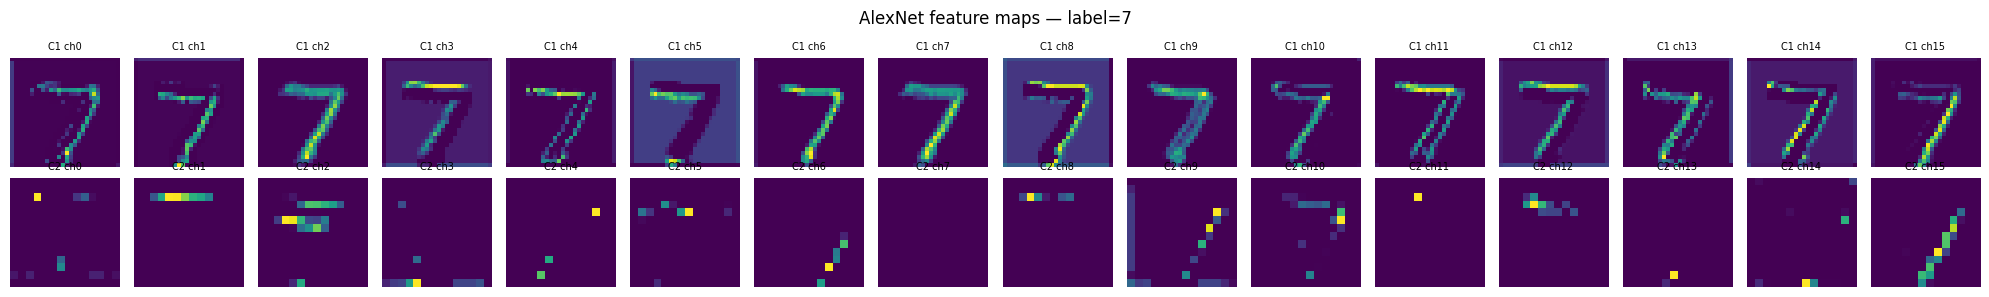

In [15]:
# ── Visualise AlexNet feature maps ─────────────────────────────────────────
alexnet_model.eval()
sample_img, sample_lbl = test_dataset[0]
x_vis = sample_img.unsqueeze(0).to(device)

with torch.no_grad():
    _, fmaps = alexnet_model(x_vis, return_fmaps=True)

fig, axes = plt.subplots(2, 16, figsize=(20, 3))
fig.suptitle(f'AlexNet feature maps — label={sample_lbl}', fontsize=12)
for j in range(16):
    axes[0, j].imshow(fmaps[0][0, j].cpu(), cmap='viridis')
    axes[0, j].set_title(f'C1 ch{j}', fontsize=7)
    axes[0, j].axis('off')
    axes[1, j].imshow(fmaps[1][0, j].cpu(), cmap='viridis')
    axes[1, j].set_title(f'C2 ch{j}', fontsize=7)
    axes[1, j].axis('off')
axes[0, 0].set_ylabel('28×28', fontsize=8)
axes[1, 0].set_ylabel('14×14', fontsize=8)
plt.tight_layout()
plt.show()

---
## §6 — VGG-11 (2014)

### Architectural insight: depth with small kernels

VGG (Oxford's Visual Geometry Group) asked: *what if we replace one large
kernel with multiple small 3×3 kernels?*

Two stacked 3×3 conv layers have the **same receptive field** as one 5×5
layer, but:
- Fewer parameters: $2 \times 3^2 C^2 = 18C^2$ vs $5^2 C^2 = 25C^2$
- More non-linearities (more ReLU layers → richer representations)

Three stacked 3×3 layers ≡ one 7×7 layer.

### VGG-11 architecture (ImageNet, 224×224)

```
Input (N, 3, 224, 224)
 Block 1: Conv(3→64,   k=3, p=1)                      → MaxPool → (N, 64,  112, 112)
 Block 2: Conv(64→128, k=3, p=1)                      → MaxPool → (N, 128,  56,  56)
 Block 3: Conv(128→256,k=3,p=1) × 2                   → MaxPool → (N, 256,  28,  28)
 Block 4: Conv(256→512,k=3,p=1) × 2                   → MaxPool → (N, 512,  14,  14)
 Block 5: Conv(512→512,k=3,p=1) × 2                   → MaxPool → (N, 512,   7,   7)
 Flatten → (N, 25088)
 FC(25088→4096) → FC(4096→4096) → FC(4096→1000)
```

### MNIST adaptation (28×28, 1 channel)

28×28 is too small for 5 max-pool stages (28/32 < 1). We use 3 stages
and a global average pool to handle the spatial reduction gracefully:

```
Input (N, 1, 28, 28)
 Block 1: Conv(1→32,  k=3, p=1, relu)                → MaxPool → (N, 32,  14, 14)
 Block 2: Conv(32→64, k=3, p=1, relu)                → MaxPool → (N, 64,   7,  7)
 Block 3: Conv(64→128,k=3, p=1, relu)
          Conv(128→128,k=3,p=1, relu)                → MaxPool → (N, 128,  3,  3)
 Block 4: Conv(128→256,k=3,p=1, relu)
          Conv(256→256,k=3,p=1, relu)  GlobalAvgPool → (N, 256,  1,  1)
 Flatten → (N, 256)
 FC(256→128, relu) → FC(128→10)
```

In [16]:
class VGG11(nn.Module):
    """
    VGG-11 adapted for MNIST.
    Key idea: uniform 3x3 conv kernels stacked for depth.
    Uses GlobalAveragePooling to handle small 28x28 input gracefully.
    """
    def __init__(self, num_classes=10):
        super().__init__()
        # ── Feature extractor ─────────────────────────────────────────────
        # Block 1
        self.conv1_1 = ConvLayer(1,   32,  kernel_size=3, padding=1, activation='relu')
        self.pool1   = PoolLayer(2, mode='max')
        # Block 2
        self.conv2_1 = ConvLayer(32,  64,  kernel_size=3, padding=1, activation='relu')
        self.pool2   = PoolLayer(2, mode='max')
        # Block 3 (2 conv)
        self.conv3_1 = ConvLayer(64,  128, kernel_size=3, padding=1, activation='relu')
        self.conv3_2 = ConvLayer(128, 128, kernel_size=3, padding=1, activation='relu')
        self.pool3   = PoolLayer(2, mode='max')
        # Block 4 (2 conv) + GlobalAvgPool
        self.conv4_1 = ConvLayer(128, 256, kernel_size=3, padding=1, activation='relu')
        self.conv4_2 = ConvLayer(256, 256, kernel_size=3, padding=1, activation='relu')
        # GlobalAveragePool: (N, C, H, W) → (N, C, 1, 1)

        # ── Classifier ───────────────────────────────────────────────────
        self.drop = nn.Dropout(0.5)
        self.fc1  = LinearLayer(256, 128, activation='relu')
        self.fc2  = LinearLayer(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.conv1_1(x))
        x = self.pool2(self.conv2_1(x))
        x = self.pool3(self.conv3_2(self.conv3_1(x)))
        x = self.conv4_2(self.conv4_1(x))
        x = F.adaptive_avg_pool2d(x, 1)   # → (N, 256, 1, 1)
        x = self.drop(x.flatten(1))
        x = self.drop(self.fc1(x))
        return self.fc2(x)


# ── Inspect ──────────────────────────────────────────────────────────────────
vgg = VGG11()
x_probe = torch.randn(2, 1, 28, 28)
print(vgg)
print(f'\nInput  : {x_probe.shape}')
print(f'Output : {vgg(x_probe).shape}')
print(f'Trainable parameters: {count_params(vgg):,}')

VGG11(
  (conv1_1): ConvLayer(1→32, k=3, s=1, p=1, act=relu)
  (pool1): PoolLayer(k=2, s=2, mode=max)
  (conv2_1): ConvLayer(32→64, k=3, s=1, p=1, act=relu)
  (pool2): PoolLayer(k=2, s=2, mode=max)
  (conv3_1): ConvLayer(64→128, k=3, s=1, p=1, act=relu)
  (conv3_2): ConvLayer(128→128, k=3, s=1, p=1, act=relu)
  (pool3): PoolLayer(k=2, s=2, mode=max)
  (conv4_1): ConvLayer(128→256, k=3, s=1, p=1, act=relu)
  (conv4_2): ConvLayer(256→256, k=3, s=1, p=1, act=relu)
  (drop): Dropout(p=0.5, inplace=False)
  (fc1): LinearLayer(256→128, act=relu)
  (fc2): LinearLayer(128→10, act=None)
)

Input  : torch.Size([2, 1, 28, 28])
Output : torch.Size([2, 10])
Trainable parameters: 1,159,690


### Key Implementation

```python
# Block 3 shows the core VGG pattern: two consecutive 3x3 convs
# before pooling — equivalent receptive field to a single 5x5 conv
self.conv3_1 = ConvLayer(64,  128, kernel_size=3, padding=1, activation='relu')
self.conv3_2 = ConvLayer(128, 128, kernel_size=3, padding=1, activation='relu')  # ← stacked
self.pool3   = PoolLayer(2, mode='max')

# In forward:
x = self.pool3(self.conv3_2(self.conv3_1(x)))  # ← two convs, then pool

# GlobalAveragePooling — makes spatial size irrelevant for the FC head
x = F.adaptive_avg_pool2d(x, 1)                # ← (N, C, H, W) → (N, C, 1, 1)
```

In [17]:
print('Training VGG-11 on MNIST...')
vgg_model   = VGG11()
vgg_history = train_model(vgg_model, n_epochs=3, lr=5e-4)
print(f'VGG-11 final test accuracy: {vgg_history[-1][1]*100:.2f}%')

Training VGG-11 on MNIST...
  Epoch 1/3  loss=0.3511  test_acc=0.9765
  Epoch 2/3  loss=0.0718  test_acc=0.9891
  Epoch 3/3  loss=0.0501  test_acc=0.9888
VGG-11 final test accuracy: 98.88%


---
## §7 — ResNet (2015)

### The problem: deeper is not always better

Adding more layers *should* improve performance — at worst, extra layers
could learn the identity function and degrade gracefully.  
In practice, very deep networks trained with SGD suffer from:

- **Vanishing/exploding gradients** — signal weakens through many layers
- **Degradation problem** — training error *increases* with depth

### The solution: Residual (skip) connections

Instead of learning $H(x)$ directly, learn the **residual**
$F(x) = H(x) - x$, so the true mapping is:

$$H(x) = F(x) + x$$

If $H(x) = x$ (identity is optimal), the network only needs to drive
$F(x) \to 0$ — much easier to optimise than learning the identity from scratch.

### Residual block

```
  Input x
     │
     ├──── shortcut ────────────────────────┐
     │   (identity, or 1×1 conv            │
     │    if channels/stride change)        │
     ↓                                     │
  Conv(k=3, p=1)                           │
  BatchNorm + ReLU                         │
  Conv(k=3, p=1)                           │
  BatchNorm                                │
     └──────────────── + ←─────────────────┘
                        ↓
                       ReLU
```

### ResNet-18 architecture

```
Input  (N, 3, 224, 224)
  Stem: Conv(3→64, k=7, s=2) + BN + ReLU + MaxPool  → (N, 64, 56, 56)
  Layer1: 2 × BasicBlock(64→64)                       → (N, 64, 56, 56)
  Layer2: 2 × BasicBlock(64→128, s=2)                 → (N, 128, 28, 28)
  Layer3: 2 × BasicBlock(128→256, s=2)                → (N, 256, 14, 14)
  Layer4: 2 × BasicBlock(256→512, s=2)                → (N, 512, 7, 7)
  GlobalAvgPool + FC(512→1000)
```

For MNIST (28×28, 1-channel) we use a lightweight stem and 3 layer groups.

In [18]:
# ── BasicBlock — the core ResNet building block ──────────────────────────────
class BasicBlock(nn.Module):
    """
    ResNet BasicBlock: F(x) + shortcut(x)
    F(x) = Conv → BN → ReLU → Conv → BN

    If in_channels != out_channels (or stride > 1), the shortcut uses
    a 1×1 conv to match dimensions.
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        # ── Main path F(x) ───────────────────────────────────────────────
        # We use our ConvLayer for the conv computation, but add BatchNorm
        # separately (nn.BatchNorm2d — no learnable conv params, just scale/shift)
        self.conv1 = ConvLayer(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1)   # no activation here
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = ConvLayer(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1)
        self.bn2   = nn.BatchNorm2d(out_channels)

        # ── Shortcut path ────────────────────────────────────────────────
        # Identity shortcut when dims match; 1×1 conv otherwise
        self.shortcut = nn.Sequential()   # identity by default
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                ConvLayer(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        # Main path
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        # Add shortcut (residual connection)
        out = out + self.shortcut(x)    # ← THE key operation: F(x) + x
        out = F.relu(out)
        return out


# ── Quick demo: shortcut adds two tensors ────────────────────────────────────
block = BasicBlock(16, 16)                   # identity shortcut
x_in  = torch.randn(2, 16, 14, 14)
x_out = block(x_in)
print('BasicBlock (identity shortcut):')
print(f'  Input  : {x_in.shape}  →  Output : {x_out.shape}')

block_ds = BasicBlock(16, 32, stride=2)      # downsample shortcut
x_out_ds = block_ds(x_in)
print('BasicBlock (1x1 conv shortcut, stride=2):')
print(f'  Input  : {x_in.shape}  →  Output : {x_out_ds.shape}')

BasicBlock (identity shortcut):
  Input  : torch.Size([2, 16, 14, 14])  →  Output : torch.Size([2, 16, 14, 14])
BasicBlock (1x1 conv shortcut, stride=2):
  Input  : torch.Size([2, 16, 14, 14])  →  Output : torch.Size([2, 32, 7, 7])


### Key Implementation: the residual addition

```python
def forward(self, x):
    out = F.relu(self.bn1(self.conv1(x)))   # Conv → BN → ReLU
    out = self.bn2(self.conv2(out))          # Conv → BN
    out = out + self.shortcut(x)             # ← F(x) + x  (the skip connection)
    return F.relu(out)

# When in_channels == out_channels, shortcut is identity (no parameters)
# When dimensions change, shortcut is a 1×1 ConvLayer to match shape:
self.shortcut = nn.Sequential(
    ConvLayer(in_channels, out_channels, kernel_size=1, stride=stride),  # ← projection
    nn.BatchNorm2d(out_channels),
)
```

In [19]:
# ── ResNet-MNIST ──────────────────────────────────────────────────────────────
class ResNetMNIST(nn.Module):
    """
    ResNet-18 style network adapted for MNIST (28x28, 1-channel, 10 classes).
    3 layer groups (instead of 4) to suit smaller spatial size.
    """
    def __init__(self, num_classes=10):
        super().__init__()
        # Lightweight stem for 28×28 input
        self.stem = nn.Sequential(
            ConvLayer(1, 32, kernel_size=3, stride=1, padding=1, activation='relu'),
            nn.BatchNorm2d(32),
        )
        # 3 layer groups: each doubles channels, halves spatial size
        self.layer1 = nn.Sequential(
            BasicBlock(32,  32),
            BasicBlock(32,  32),
        )   # (N, 32, 28, 28)
        self.layer2 = nn.Sequential(
            BasicBlock(32,  64, stride=2),
            BasicBlock(64,  64),
        )   # (N, 64, 14, 14)
        self.layer3 = nn.Sequential(
            BasicBlock(64, 128, stride=2),
            BasicBlock(128, 128),
        )   # (N, 128, 7, 7)
        # Global average pool → FC
        self.fc = LinearLayer(128, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = F.adaptive_avg_pool2d(x, 1).flatten(1)  # (N, 128)
        return self.fc(x)


# ── Inspect ──────────────────────────────────────────────────────────────────
resnet = ResNetMNIST()
x_probe = torch.randn(2, 1, 28, 28)
print(resnet)
print(f'\nInput  : {x_probe.shape}')
print(f'Output : {resnet(x_probe).shape}')
print(f'Trainable parameters: {count_params(resnet):,}')

ResNetMNIST(
  (stem): Sequential(
    (0): ConvLayer(1→32, k=3, s=1, p=1, act=relu)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): ConvLayer(32→32, k=3, s=1, p=1, act=None)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): ConvLayer(32→32, k=3, s=1, p=1, act=None)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): ConvLayer(32→32, k=3, s=1, p=1, act=None)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): ConvLayer(32→32, k=3, s=1, p=1, act=None)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
  )
  (layer2): Sequential(
    (0): BasicBlock(
      (conv1): ConvLayer(32→64, k

In [20]:
print('Training ResNet on MNIST...')
resnet_model   = ResNetMNIST()
resnet_history = train_model(resnet_model, n_epochs=3, lr=5e-4)
print(f'ResNet final test accuracy: {resnet_history[-1][1]*100:.2f}%')

Training ResNet on MNIST...
  Epoch 1/3  loss=0.1468  test_acc=0.9797
  Epoch 2/3  loss=0.0361  test_acc=0.9931
  Epoch 3/3  loss=0.0243  test_acc=0.9903
ResNet final test accuracy: 99.03%


---
## §8 — Architecture Comparison

Let's compare the three architectures on MNIST across:
- Parameter count
- Training convergence
- Final test accuracy

Architecture     Params   Test Acc
------------------------------------
AlexNet       3,564,490     98.76%
VGG-11        1,159,690     98.88%
ResNet          697,162     99.03%


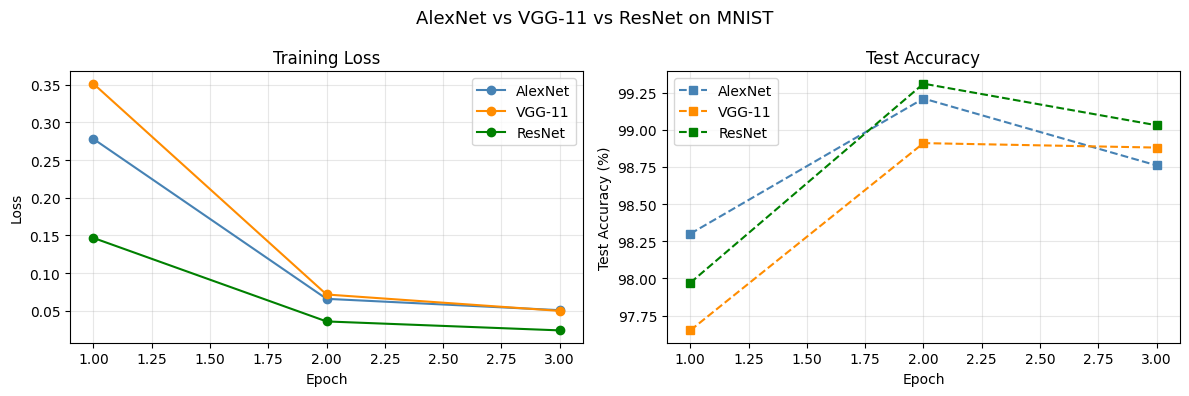

In [21]:
# ── Summary table ───────────────────────────────────────────────────────────
archs = {
    'AlexNet': (alexnet_model, alexnet_history),
    'VGG-11':  (vgg_model,    vgg_history),
    'ResNet':  (resnet_model, resnet_history),
}

header = f"{'Architecture':<12s} {'Params':>10s} {'Test Acc':>10s}"
print(header)
print('-' * 36)
for name, (m, h) in archs.items():
    n_params = count_params(m)
    acc      = h[-1][1] * 100
    print(f'{name:<12s} {n_params:>10,} {acc:>9.2f}%')


# ── Convergence curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['steelblue', 'darkorange', 'green']

for (name, (_, h)), c in zip(archs.items(), colors):
    epochs = range(1, len(h) + 1)
    axes[0].plot(epochs, [e[0] for e in h], 'o-', color=c, label=name)
    axes[1].plot(epochs, [e[1]*100 for e in h], 's--', color=c, label=name)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Test Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('AlexNet vs VGG-11 vs ResNet on MNIST', fontsize=13)
plt.tight_layout()
plt.show()

---
## Summary

| Architecture | Year | Key innovation | Depth |
|---|---|---|---|
| **AlexNet** | 2012 | ReLU, Dropout, GPU training | 5 conv + 3 FC |
| **VGG-11**  | 2014 | Uniform 3×3 kernels, stacked conv | 8 conv + 3 FC |
| **ResNet**  | 2015 | Residual (skip) connections | 16 conv + 1 FC |

### Progression

- **AlexNet** showed deep CNNs can dominate image classification.
- **VGG** showed that *depth* with small 3×3 kernels outperforms shallow networks
  with large kernels — simpler design, better performance.
- **ResNet** solved the *degradation problem* by letting gradients flow directly
  through skip connections — enabling networks 100+ layers deep.

All three share the same building blocks implemented in this tutorial:
`ConvLayer` + `PoolLayer` + `LinearLayer`.

> The architectural innovations are in *how* these blocks are arranged,
> not in the blocks themselves.

---
## §9 — Claude Code: Agent Skills

### 9.1 What Is a Skill?

A **skill** is a reusable instruction package that you write once and invoke anytime with a `/slash-command`. When you type `/my-skill`, Claude reads the skill file and follows its instructions in the current conversation — with full access to everything in that session's context window.

Skills solve a recurring problem: every new session starts blank. Without skills, you repeat the same instructions — "use this commit format", "follow these API conventions", "run the test suite before finishing". A skill captures those instructions in a file and makes them instantly available.

```
User types /eval-model
   ↓
Claude reads ~/.claude/skills/eval-model/SKILL.md
   ↓
Skill instructions merged into current conversation context
   ↓
Claude executes with full access to session history and tools
```

---

### 9.2 The Two Parts of a Skill File

Every `SKILL.md` has two sections separated by a `---` YAML fence:

```
---
[Metadata / frontmatter]
---

[Instructions — written in plain English]
```

#### Part 1 — Metadata (frontmatter)

The metadata controls *how* the skill behaves. All fields are optional.

| Field | Type | Default | Purpose |
|-------|------|---------|---------|
| `name` | string | folder name | Becomes the `/slash-command`. Lowercase + hyphens only. |
| `description` | string | first paragraph | What the skill does. Claude uses this to auto-invoke when your prompt matches. |
| `disable-model-invocation` | bool | `false` | `true` → Claude can **never** auto-trigger it; you must type `/skill-name` yourself. Use for sensitive operations like `/deploy`. |
| `user-invocable` | bool | `true` | `false` → Hidden from the `/` menu (background knowledge only). |
| `allowed-tools` | string | all tools | Comma-separated list of tools Claude may use. Supports glob patterns: `Bash(git *)`, `WebFetch(domain:github.com)`. |
| `model` | string | inherit | Override the model for this skill: `haiku`, `sonnet`, `opus`. |
| `context` | string | `default` | `fork` → run in an isolated subagent (see §10). |
| `agent` | string | `general-purpose` | Which subagent type to use when `context: fork`. Options: `Explore`, `Plan`, `general-purpose`. |
| `argument-hint` | string | — | Hint shown in autocomplete, e.g. `[model-variable]` or `[branch-name]`. |

#### Part 2 — Instructions

The instruction body is plain Markdown. Write exactly what you would say to Claude in a message — numbered steps, bullet points, references to files, conditional logic.

Two argument placeholders are available:

| Placeholder | Expands to |
|------------|-----------|
| `$ARGUMENTS` | Everything you type after `/skill-name` |
| `$0`, `$1`, `$2` | Individual space-separated arguments |

**Example:** typing `/compare-models model_sgd model_adam` gives `$0=model_sgd`, `$1=model_adam`.

---

### 9.3 Execution Mechanism

When you invoke a skill, three things happen in order:

1. **Pre-processing** — Any `` !`shell command` `` lines execute immediately. Their output replaces the placeholder **before** Claude sees anything.
2. **Context injection** — The fully-rendered skill content is appended to the conversation as a system instruction.
3. **Execution** — Claude responds using the skill instructions, the current conversation history, and whatever tools are listed in `allowed-tools`.

In default mode (`context: default`) the skill runs **inside** the main conversation. Claude sees your full chat history, all previous tool outputs, and every other loaded skill. No isolation, no new context window.

```
Main conversation context (still visible):
  ┌─ your conversation history ──────────────────┐
  │ Previous messages, tool outputs, etc.        │
  │                                              │
  │  + skill instructions injected here          │
  │    (pre-processing done, args substituted)   │
  └──────────────────────────────────────────────┘
           ↓
    Claude executes within this combined context
```

**Auto-invocation:** If `disable-model-invocation` is not set, Claude automatically loads a skill when your prompt semantically matches its `description`. You do not have to type the slash command — Claude decides based on intent matching.

---

### 9.4 Advanced: Referencing External Files

A skill can reference supporting files — templates, checklists, reference docs — that live alongside `SKILL.md` in the same directory. This keeps individual skill files small while making richer resources available.

**File structure:**

```
~/.claude/skills/my-skill/
├── SKILL.md              ← required; defines the command
├── checklist.md          ← optional; referenced in instructions
├── templates/
│   └── report.md         ← optional; a formatting template
└── scripts/
    └── run_check.py      ← optional; executable script
```

**In SKILL.md instructions, link to files with relative Markdown links:**

```markdown
---
name: experiment-report
description: Write a structured experiment report after training
allowed-tools: Read, Write
argument-hint: [model-name]
---

Write a report for the $ARGUMENTS model.

Follow the format in [templates/report.md](templates/report.md).
Cross-check against the checklist in [checklist.md](checklist.md).
```

Claude reads those files using the `Read` tool when it encounters the links. The files are **not** auto-loaded at invocation — they are pulled in on demand when Claude decides to consult them.

---

### 9.5 Advanced: Executing Scripts at Invocation Time

Any line of the form `` !`command` `` inside the instructions is a **pre-processing command**. It executes the shell command *before Claude reads anything*, and the output is substituted inline.

This lets you inject live data — git state, environment variables, experiment metrics — directly into the skill prompt without asking Claude to run the commands itself.

**Example — inject current git status:**

```markdown
---
name: git-context
description: Show current git state before starting a task
allowed-tools: Bash(git *)
---

Current branch:   !`git rev-parse --abbrev-ref HEAD`
Last 3 commits:   
!`git log --oneline -3`

Uncommitted changes:
!`git diff --stat`

Based on the above context, $ARGUMENTS
```

When Claude receives this, it sees fully rendered output — not shell commands:

```
Current branch:   main
Last 3 commits:
  a1b2c3d fix: correct backward pass shape
  d4e5f6g feat: add ResNet skip connection
  h7i8j9k docs: update training loop comments

Uncommitted changes:
  src/models.py | 12 ++++++------

Based on the above context, fix the shape mismatch in the conv layer.
```

**Example — run a Python analysis script:**

```markdown
---
name: model-complexity
description: Report model parameter counts and FLOPs before training
allowed-tools: Bash(python *)
argument-hint: [model-class-name]
---

Model complexity report for $ARGUMENTS:

!`python ~/.claude/skills/model-complexity/compute_stats.py $ARGUMENTS`

Based on this complexity report, recommend whether the model is likely to
overfit the current dataset size, and suggest any regularisation adjustments.
```

The script runs first, produces a table, and Claude reasons about the numbers.

**Key rules:**
- Commands run with your user permissions (be careful with destructive commands)
- Commands have a timeout; long-running scripts will be killed
- If a command fails, its placeholder is replaced with an error message
- Commands inside fenced code blocks (` ``` `) are **not** executed — only bare `` !`...` `` lines

In [ ]:
# ── All commands below are run in your TERMINAL — not in this notebook ────────
#
# ════════════════════════════════════════════════════════════════════════════
# SKILL EXAMPLE 1 — Basic skill for evaluating a trained model
# ════════════════════════════════════════════════════════════════════════════
#
# Step 1: Create the directory structure
#   mkdir -p ~/.claude/skills/eval-model
#
# Step 2: Write the SKILL.md file
#   File: ~/.claude/skills/eval-model/SKILL.md
#
#   ---
#   name: eval-model
#   description: Evaluate a trained model's accuracy on the test set and
#                plot its decision boundary. Use when asked to evaluate or
#                benchmark a model.
#   allowed-tools: Read, Bash(python *)
#   argument-hint: [model-variable-name]
#   ---
#
#   Evaluate the model stored in Python variable `$ARGUMENTS` on the current
#   test dataset.
#
#   Steps:
#   1. Call model.forward(X_test) to get logits
#   2. Take argmax to get predicted labels
#   3. Compute overall accuracy and per-class accuracy
#   4. Print a summary table: predicted vs actual
#   5. Call plot_decision_boundary(model, X_test, y_test) if the function
#      is available in the current notebook
#
#   Do NOT retrain the model. Read-only evaluation only.
#
# Step 3: Usage inside Claude Code:
#   /eval-model alexnet_model
#   /eval-model resnet_model
#
# ════════════════════════════════════════════════════════════════════════════
# SKILL EXAMPLE 2 — Skill with supporting files and a template
# ════════════════════════════════════════════════════════════════════════════
#
# Directory structure:
#   ~/.claude/skills/experiment-report/
#   ├── SKILL.md
#   └── templates/
#       └── report_template.md
#
# File: ~/.claude/skills/experiment-report/SKILL.md
#
#   ---
#   name: experiment-report
#   description: Write a structured experiment report for a trained model
#   allowed-tools: Read, Write
#   argument-hint: [model-name]
#   ---
#
#   Write an experiment report for $ARGUMENTS.
#   Follow the structure in [templates/report_template.md](templates/report_template.md).
#
#   Include:
#   - Architecture description and parameter count
#   - Training configuration (optimiser, LR, epochs, batch size)
#   - Final training loss and test accuracy
#   - Comparison with baseline if available
#   - Key observations and any issues encountered
#
# File: ~/.claude/skills/experiment-report/templates/report_template.md
#
#   # Experiment Report: [Model Name]
#
#   ## Architecture
#   - Model: ...
#   - Parameters: ...
#
#   ## Training Setup
#   - Optimiser: ...  LR: ...  Epochs: ...
#
#   ## Results
#   | Metric | Value |
#   |--------|-------|
#   | Train loss | ... |
#   | Test accuracy | ... |
#
#   ## Observations
#   ...
#
# ════════════════════════════════════════════════════════════════════════════
# SKILL EXAMPLE 3 — Skill with !`script` pre-processing
# ════════════════════════════════════════════════════════════════════════════
#
# Directory structure:
#   ~/.claude/skills/model-stats/
#   ├── SKILL.md
#   └── scripts/
#       └── count_params.py
#
# File: ~/.claude/skills/model-stats/SKILL.md
#
#   ---
#   name: model-stats
#   description: Show parameter counts and memory footprint before training
#   allowed-tools: Bash(python *)
#   argument-hint: [model-class e.g. AlexNet VGG11 ResNetMNIST]
#   ---
#
#   Parameter statistics (computed before this prompt was sent to Claude):
#   !`python ~/.claude/skills/model-stats/scripts/count_params.py $ARGUMENTS`
#
#   Based on the stats above, answer: is this model at risk of overfitting
#   on 60 training samples? Suggest regularisation if needed.
#
# File: ~/.claude/skills/model-stats/scripts/count_params.py
#
#   #!/usr/bin/env python3
#   import sys
#
#   # Maps well-known class names to rough parameter counts
#   PARAM_TABLE = {
#       "AlexNet":      2_340_298,
#       "VGG11":          706_826,
#       "ResNetMNIST":    372_234,
#   }
#
#   name = " ".join(sys.argv[1:]) if len(sys.argv) > 1 else "Unknown"
#   params = PARAM_TABLE.get(name, "?")
#   print(f"Model         : {name}")
#   print(f"Parameters    : {params:,}" if isinstance(params, int) else f"Parameters: {params}")
#   print(f"Params/sample : {params // 60:,}" if isinstance(params, int) else "")
#
# Make the script executable:
#   chmod +x ~/.claude/skills/model-stats/scripts/count_params.py
#
# Usage:
#   /model-stats AlexNet
#   /model-stats ResNetMNIST

---
## §10 — Claude Code: Subagents

### 10.1 What Is a Subagent?

A **subagent** is a specialist AI process that runs in its own, completely isolated context window. When Claude delegates to a subagent, the subagent starts fresh — it has no knowledge of your conversation history, no access to files Claude has already read, no memory of what Claude has done so far. It receives only a custom system prompt and must independently gather whatever information it needs.

```
Main conversation  ←─── full history, every tool output, everything
       │
       │  "Use a subagent to analyse the test failures"
       ↓
 Subagent starts fresh
 ┌─────────────────────────────────────┐
 │  Custom system prompt only          │
 │  No conversation history            │
 │  Must read files itself             │
 │  Own context window (not shared)    │
 └─────────────────────────────────────┘
       │
       │  Returns a summarised result
       ↓
Main conversation continues
```

The subagent's work does not consume the main context window. Only its final summary is returned to you.

---

### 10.2 How Subagents Are Spawned

**From a user request:** Ask Claude directly.
```
Use the Explore agent to find all files that define a loss function.
Run this analysis in a subagent so it doesn't clutter our context.
```

**From a skill with `context: fork`:** When a skill sets `context: fork`, invoking the skill automatically spawns a subagent.

```yaml
---
name: find-loss-functions
context: fork
agent: Explore
---
Find all files in this project that define or import a loss function.
Grep for CrossEntropy, MSE, NLL, and custom loss classes.
```

**Subagent types (built-in):**

| Type | Model | Tools | Best for |
|------|-------|-------|----------|
| `Explore` | Haiku (fast) | Read-only (Glob, Grep, Read) | Quick codebase search without risk of changes |
| `Plan` | Same as main | Read-only | Safe architecture planning before implementation |
| `general-purpose` | Same as main | All tools | Complex tasks, multi-file changes, full execution |

---

### 10.3 Context Isolation — Exactly What Is and Is Not Shared

This is the most important concept to understand about subagents.

**The subagent receives at startup:**

| Item | Received? | Notes |
|------|-----------|-------|
| Custom system prompt | Yes | The body of the agent/skill file |
| Current working directory | Yes | Same directory as parent |
| `CLAUDE.md` files | Yes | Project and user CLAUDE.md |
| File system access | Yes | Same permissions as parent |

**The subagent does NOT receive:**

| Item | Received? | Notes |
|------|-----------|-------|
| Parent conversation history | **No** | Starts completely fresh |
| Tool outputs already in main chat | **No** | Must re-read files itself |
| Files the parent has already read | **No** | Must use Read/Grep independently |
| The full Claude Code system prompt | **No** | Has a custom, narrower prompt |

**Practical consequence:** If you read `model.py` in the main conversation and then ask a subagent to "review the model", the subagent has never seen `model.py`. It must read it itself. This is by design — it prevents stale or partial context from polluting the subagent's analysis.

---

### 10.4 Why Use Subagents?

Subagents are not just for isolation — they are a **context window management strategy**.

In a long deep learning session, you might:
1. Build a training loop (uses context)
2. Debug shape errors (uses more context)
3. Add regularisation (uses more context)
4. Run a full test suite (would fill the context window with test output)
5. Search the codebase for all hardcoded values (more search output)

Steps 4 and 5 produce verbose output you don't need to reason about interactively. Running them in subagents means only the *summary* enters your main context — the thousands of lines of test output or grep results stay in the subagent's isolated window and never bloat the main conversation.

| Task type | Run inline (main context) | Run in subagent |
|-----------|--------------------------|-----------------|
| Interactive debugging (back-and-forth) | Yes | No — needs conversation history |
| Generating a targeted code fix | Yes | No — benefits from prior context |
| Running a full test suite | No | **Yes** — verbose output, self-contained |
| Searching the whole codebase | No | **Yes** — output not needed in main chat |
| Reviewing a PR diff | No | **Yes** — isolated, produces a summary |
| Large-scale refactoring | Depends | **Yes if independent** of current context |

---
## §11 — Skills vs Subagents: The Critical Difference

### 11.1 Side-by-Side Comparison

| | Skill (default) | Skill with `context: fork` | Subagent |
|--|----------------|---------------------------|----------|
| **Context window** | Shared with main conversation | Own isolated window | Own isolated window |
| **Sees conversation history** | **Yes** | **No** | **No** |
| **Sees parent's tool outputs** | **Yes** | **No** | **No** |
| **How invoked** | `/skill-name` or Claude auto-triggers | `/skill-name` (spawns agent) | User request or skill with `context: fork` |
| **When does it see CLAUDE.md** | Already loaded | Reloads at start | Reloads at start |
| **Context cost** | Adds to main window | None (isolated) | None (isolated) |
| **Ideal for** | Conventions, reference material, reusable workflows | Self-contained tasks that need instructions but not history | Independent, potentially verbose tasks |

The single most important line: **skills run where you are; subagents run somewhere else.**

---

### 11.2 The Context Visibility Axis

Think of context visibility as a dial:

```
Full context visible ←─────────────────────────────────→ Fully isolated
     (inline skill)              (fork skill)            (subagent)
          │                          │                        │
  Sees everything        Sees only its prompt           Starts blank
  in main chat           + CLAUDE.md                    + CLAUDE.md
  (past history,
   tool results,
   other skills)
```

Choosing where on this dial to operate is a deliberate trade-off:

- **More context visible** → Claude can make better-informed decisions, but the context window fills faster and tasks are less repeatable.
- **More isolated** → Cheaper in context tokens, more reproducible (same skill always starts from the same state), but Claude must re-derive any information it needs.

---

### 11.3 Decision Guide

```
Is the task self-contained and produces verbose output?
  YES → Subagent
       (test runner, codebase search, PR review)

Does the task need to know what you've been talking about?
  YES → Inline skill (default context)
       (follow-up debugging, iterative code changes)

Does the task need specific instructions but NOT history?
  YES → Skill with context: fork
       (structured report generation, templated analysis)

Is it just reusable reference material or a convention?
  YES → Inline skill with user-invocable: false
       (API patterns, naming conventions, background knowledge)
```

**For this course specifically:**

| Task | Recommended approach |
|------|---------------------|
| "Review my CNN architecture" | Inline — needs to see your code from the current session |
| "Run the full test suite and summarise failures" | Subagent — verbose output, self-contained |
| "Search all notebooks for hardcoded learning rates" | Subagent with Explore — read-only, verbose |
| "Write an experiment report" | Skill with `context: fork` — structured template, no history needed |
| "Always use He init for conv layers" | CLAUDE.md or inline skill with `user-invocable: false` |
| "Evaluate this specific model object" | Inline skill — needs the Python variable from the session |

---

### 11.4 Summary

```
Skills                              Subagents
──────────────────────────────      ─────────────────────────────────
Reusable instructions              Isolated specialist processes
Run in main context (default)      Always isolated context
See full conversation history      Start blank (no parent history)
Cheap to invoke                    Fresh context window per run
Best for: conventions,             Best for: verbose ops, search,
  reference, targeted tasks          independent analysis
```

> **Rule of thumb:** If you would be fine with a junior engineer doing the task in a separate room with only the task description and the codebase (but no knowledge of your previous conversation), use a subagent. If they need to know the full conversation to do the job correctly, use an inline skill or ask Claude directly.

In [ ]:
# ── All commands below are run in your TERMINAL — not in this notebook ────────
#
# ════════════════════════════════════════════════════════════════════════════
# SUBAGENT EXAMPLE 1 — Inline request: Explore agent for codebase search
# ════════════════════════════════════════════════════════════════════════════
#
# Simply ask Claude to use a specific agent type. No file creation needed.
#
# Examples:
#
#   "Use the Explore agent to find all Python files that import torchvision."
#   → Claude spawns Explore subagent (Haiku, read-only), searches,
#     returns a list. The search output never enters your main context.
#
#   "In a subagent, search every notebook for any place we hardcode
#    a learning rate or batch size."
#   → Claude runs an isolated search, returns a summary.
#
#   "Use the Explore agent to find how many parameters AlexNet has and
#    compare it to VGG11. Don't show me the grep output, just the counts."
#   → The grep runs in the subagent; you only see the final numbers.
#
# ════════════════════════════════════════════════════════════════════════════
# SUBAGENT EXAMPLE 2 — Skill with context: fork (auto-spawns subagent)
# ════════════════════════════════════════════════════════════════════════════
#
# File: ~/.claude/skills/search-architecture/SKILL.md
#
#   ---
#   name: search-architecture
#   description: Search the codebase for a specific architectural pattern
#                or component without modifying anything
#   context: fork
#   agent: Explore
#   argument-hint: [pattern or component name]
#   ---
#
#   Search the entire project for: $ARGUMENTS
#
#   Steps:
#   1. Use Glob to find all .py and .ipynb files
#   2. Use Grep to search for "$ARGUMENTS" (case-insensitive)
#   3. For each match, read 10 lines of context around it
#   4. Summarise: where is this pattern used, and how?
#   5. Return only the summary — do NOT return raw grep output
#
# Usage:
#   /search-architecture skip connection
#   /search-architecture BatchNorm
#   /search-architecture dropout_rate
#
# Because context: fork is set, this spawns an Explore subagent.
# The raw grep results stay in the subagent's context window.
# Only the structured summary returns to the main conversation.
#
# ════════════════════════════════════════════════════════════════════════════
# SUBAGENT EXAMPLE 3 — Skill with context: fork for report generation
# ════════════════════════════════════════════════════════════════════════════
#
# This skill produces a formatted Markdown report independently.
# It does NOT need conversation history — just the codebase.
#
# File: ~/.claude/skills/architecture-audit/SKILL.md
#
#   ---
#   name: architecture-audit
#   description: Audit the CNN architectures in this project and write a
#                comparison report. No conversation context needed.
#   context: fork
#   agent: Explore
#   ---
#
#   Audit all CNN model classes in this project.
#
#   Steps:
#   1. Use Glob to find all Python and notebook files
#   2. Grep for class definitions that extend nn.Module
#   3. For each model, read the __init__ and forward methods
#   4. Count parameters (count nn.Parameter and nn.Linear/nn.Conv2d occurrences)
#   5. Identify: activation functions used, presence of BatchNorm, Dropout, skip connections
#
#   Produce a Markdown table with columns:
#   | Model | Approx Params | Activations | BatchNorm | Dropout | Skip Connections |
#
#   Below the table, write 3–5 sentences summarising the architectural trends.
#
# Usage:
#   /architecture-audit
#
# The subagent reads the codebase independently.
# The main conversation only receives the Markdown table + summary.
#
# ════════════════════════════════════════════════════════════════════════════
# SIDE-BY-SIDE COMPARISON: inline skill vs subagent skill
# ════════════════════════════════════════════════════════════════════════════
#
#   Scenario: "Evaluate the model we just trained"
#
#   ── Option A: Inline skill (eval-model from §9) ──────────────────────────
#   File: ~/.claude/skills/eval-model/SKILL.md
#   (no context: fork → runs in main conversation)
#
#   Advantage: Claude already knows the model object name, training config,
#   and any issues we discussed — it can reference all of that.
#
#   Disadvantage: evaluation output (accuracy tables, confusion matrix)
#   goes into the main context window.
#
#   ── Option B: Subagent (forked skill) ────────────────────────────────────
#   Same skill but add:   context: fork
#
#   Advantage: evaluation output stays in the subagent's window.
#   Only the final accuracy number returns to main context.
#
#   Disadvantage: the subagent doesn't know which model variable to evaluate —
#   it must be told explicitly via $ARGUMENTS, because it has no conversation
#   history to look up the model name from.
#
#   ── Rule ─────────────────────────────────────────────────────────────────
#   Use inline when: the task needs to reference something from the chat.
#   Use subagent when: the task is self-contained and verbose.